In [ ]:
# all requirement libs
!pip install -q pyngrok streamlit pandas numpy scikit-learn matplotlib seaborn
print("Все либы установлены")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.6 MB/s eta 0:00:00
Все необходимые библиотеки установлены.


In [ ]:
# Установка Playwright
!pip install playwright

!playwright install chromium


Version 1.52.0


**Начинаем парсить данные с excel таблицы затем создать датасет**

In [ ]:
import pandas as pd

file_name = 'contract_20-06-2025_export.xls'

try:
    tables = pd.read_html(file_name, encoding='utf-8')

    if not tables:
        print("Ошибка: В загруженном HTML-файле не найдено ни одной таблицы.")
        print("Возможно, файл поврежден или таблица имеет нестандартную структуру.")
    else:
        print(f"Найдено {len(tables)} таблиц в файле '{file_name}'.")

        df = tables[0]

        print("\nПервые 5 строк данных из найденной таблицы:")
        print(df.head())

        print("\nИнформация о столбцах и типах данных:")
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        df.info()

        print("\nКраткая статистика по числовым столбцам:")
        print(df.describe())

except FileNotFoundError:
    print(f"Ошибка: Файл '{file_name}' не найден. Убедитесь, что имя файла указано правильно и он загружен в Colab.")
except Exception as e:
    print(f"Произошла ошибка при загрузке файла: {e}")
    print("Проверьте, что файл не пустой и что он действительно содержит HTML-разметку с таблицами.")

# Сбросим настройки отображения Pandas
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Найдено 1 таблиц в файле 'contract_20-06-2025_export.xls'.

Первые 5 строк данных из найденной таблицы:
          #          Номер договора Номер закупки               Тип договора  \
0  23061466  090940018516/250120/00           NaN           Основной договор   
1  23061418  210940038944/250136/01    14547370-1  Дополнительное соглашение   
2  23061398  130140006553/250041/00           NaN           Основной договор   
3  23061231  810840000017/250078/00           NaN           Основной договор   
4  23061219  050240009138/250074/00    14955683-1           Основной договор   

  Статус договора        Дата создания         Сумма  \
0       Действует  2025-06-20 18:57:42  5 013 000.00   
1       Действует  2025-06-20 18:34:09  6 250 000.00   
2       Действует  2025-06-20 18:28:07    352 876.00   
3       Действует  2025-06-20 17:56:58  1 944 000.00   
4       Действует  2025-06-20 17:55:26     11 000.00   

                                            Заказчик  \
0  государственное ком

In [ ]:
import pandas as pd
import re


print("Начинаем предобработку данных...")

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(f"Новые названия столбцов: {df.columns.tolist()}")

if 'сумма' in df.columns:
    print("\nОбработка столбца 'сумма'...")
    df['сумма'] = df['сумма'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['сумма'] = pd.to_numeric(df['сумма'], errors='coerce')
    df['сумма'] = df['сумма'].fillna(0)
    print("Столбец 'сумма' очищен и преобразован в числовой формат.")
else:
    print("\nПредупреждение: Столбец 'сумма' не найден. Проверьте название столбца.")

if 'дата_создания' in df.columns:
    print("\nОбработка столбца 'дата_создания'...")
    df['дата_создания'] = pd.to_datetime(df['дата_создания'], errors='coerce')
    initial_rows = len(df)
    df.dropna(subset=['дата_создания'], inplace=True)
    rows_dropped = initial_rows - len(df)
    print(f"Столбец 'дата_создания' преобразован в формат datetime. Удалено {rows_dropped} строк с некорректными датами.")
else:
    print("\nПредупреждение: Столбец 'дата_создания' не найден. Проверьте название столбца.")

text_cols_to_clean = [
    'номер_договора', 'номер_закупки', 'тип_договора',
    'статус_договора', 'заказчик', 'поставщик', 'способ_закупки'
]

for col in text_cols_to_clean:
    if col in df.columns:
        df[col] = df[col].fillna('').astype(str).str.strip()
        print(f"Столбец '{col}' очищен от пропущенных значений и лишних пробелов.")

if 'дата_создания' in df.columns:
    df['год_закупки'] = df['дата_создания'].dt.year
    df['месяц_закупки'] = df['дата_создания'].dt.month
    df['день_месяца_закупки'] = df['дата_создания'].dt.day
    df['день_недели_закупки'] = df['дата_создания'].dt.dayofweek # 0=понедельник, 6=воскресенье
    df['квартал_закупки'] = df['дата_создания'].dt.quarter
    print("Добавлены временные признаки.")

# Создание комбинированных признаков
df['заказчик_поставщик'] = df['заказчик'] + '_' + df['поставщик']
print("Добавлен комбинированный признак 'заказчик_поставщик'.")


print("\nПредобработка завершена.")
print(f"Размер DataFrame после предобработки: {df.shape[0]} строк, {df.shape[1]} столбцов.")

print("\nИнформация о данных после предобработки:")
print(df.info())
print("\nПервые 5 строк данных после предобработки:")
print(df.head())
print("\nКраткая статистика по числовым столбцам после предобработки:")
print(df.describe())

Начинаем предобработку данных...
Новые названия столбцов: ['#', 'номер_договора', 'номер_закупки', 'тип_договора', 'статус_договора', 'дата_создания', 'сумма', 'заказчик', 'поставщик', 'способ_закупки']

Обработка столбца 'сумма'...
Столбец 'сумма' очищен и преобразован в числовой формат.

Обработка столбца 'дата_создания'...
Столбец 'дата_создания' преобразован в формат datetime. Удалено 0 строк с некорректными датами.
Столбец 'номер_договора' очищен от пропущенных значений и лишних пробелов.
Столбец 'номер_закупки' очищен от пропущенных значений и лишних пробелов.
Столбец 'тип_договора' очищен от пропущенных значений и лишних пробелов.
Столбец 'статус_договора' очищен от пропущенных значений и лишних пробелов.
Столбец 'заказчик' очищен от пропущенных значений и лишних пробелов.
Столбец 'поставщик' очищен от пропущенных значений и лишних пробелов.
Столбец 'способ_закупки' очищен от пропущенных значений и лишних пробелов.
Добавлены временные признаки.
Добавлен комбинированный признак '

In [ ]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd
import re

# Было принято решение скрейпить описания т.к. в самих таблицах это не предполагается.
if 'df' not in locals():
    print("Создаем демонстрационный DataFrame, т.к. 'df' не найден.")
    data = {
        '#': [1, 2, 3, 4, 5],
        'номер_договора': ['090940018516/250120/00', '210940038944/250136/01', '130140006553/250041/00', '810840000017/250078/00', '050240009138/250074/00'],
        'номер_закупки': ['#', '14547370-1', '#', '#', '14955683-1'],
        'тип_договора': ['Основной договор', 'Дополнительное соглашение', 'Основной договор', 'Основной договор', 'Основной договор'],
        'статус_договора': ['Действует', 'Действует', 'Действует', 'Действует', 'Действует'],
        'дата_создания': ['2025-06-20 18:57:42', '2025-06-20 18:34:09', '2025-06-20 18:28:07', '2025-06-20 17:56:58', '2025-06-20 17:55:26'],
        'сумма': ['5 013 000.00', '6 250 000.00', '352 876.00', '1 944 000.00', '11 000.00'],
        'заказчик': ['ГКП1', 'ГКП2', 'КГКП1', 'ГКП3', 'КГУ1'],
        'поставщик': ['ИП1', 'KORVIN', 'ИП2', 'AYANA', 'ИП3'],
        'способ_закупки': ['Электронный магазин', 'Открытый конкурс', 'Электронный магазин', 'Из одного источника', 'Запрос ценовых предложений']
    }
    df = pd.DataFrame(data)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    df['сумма'] = df['сумма'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['сумма'] = pd.to_numeric(df['сумма'], errors='coerce').fillna(0)
    df['дата_создания'] = pd.to_datetime(df['дата_создания'], errors='coerce')
    df.dropna(subset=['дата_создания'], inplace=True)
    df['номер_договора'] = df['номер_договора'].astype(str).str.strip()
    print("Демонстрационный DataFrame загружен и предобработан.")
    print(f"Примеры номеров договоров: {df['номер_договора'].head().tolist()}")

# --- Функции для скрейпинга ---

async def get_contract_summary(page, contract_id):
    """
    Функция для скрейпинга "Краткого содержания договора на русском языке" по ID договора.
    Использует более надежный XPath, основанный на тексте.
    """
    if not isinstance(contract_id, str) or not contract_id.strip() or contract_id == 'nan':
        print(f"DEBUG: Пропущено: Некорректный номер договора: '{contract_id}'")
        return "Некорректный номер договора"

    detail_url = f"https://goszakup.gov.kz/ru/egzcontract/cpublic/show/{contract_id}"
    print(f"DEBUG: Пытаемся перейти на URL: {detail_url}")

    try:
        await page.goto(detail_url, wait_until="domcontentloaded", timeout=60000)
        print(f"DEBUG: Страница {detail_url} загружена.")

        # Ищем td, который содержит текст "Краткое содержание договора на русском языке"
        # Затем выбираем родительский tr (..) и следующий td (following-sibling::td)
        xpath_selector = '//td[contains(text(), "Краткое содержание договора на русском языке")]/following-sibling::td'
        print(f"DEBUG: Ищем элемент по XPath: {xpath_selector}")

        description_element = await page.wait_for_selector(f'xpath={xpath_selector}', timeout=20000)

        if description_element:
            description = await description_element.inner_text()
            print(f"DEBUG: Описание найдено для ID {contract_id}: '{description.strip()[:50]}...'")
            return description.strip()
        else:
            print(f"DEBUG: Элемент описания не найден для ID {contract_id} по XPath.")
            xpath_selector_alt = '//td[contains(text(), "Краткое содержание договора")]/following-sibling::td'
            print(f"DEBUG: Попытка найти по альтернативному XPath: {xpath_selector_alt}")
            description_element_alt = await page.wait_for_selector(f'xpath={xpath_selector_alt}', timeout=10000)
            if description_element_alt:
                description = await description_element_alt.inner_text()
                print(f"DEBUG: Описание найдено (альт) для ID {contract_id}: '{description.strip()[:50]}...'")
                return description.strip()
            else:
                 print(f"DEBUG: Элемент описания не найден для ID {contract_id} по обоим XPath.")
                 return "Описание не найдено"


    except Exception as e:
        print(f"DEBUG: ОШИБКА скрейпинга ID {contract_id} по URL {detail_url}: {e}")
        try:
            screenshot_path = f'error_screenshot_{contract_id.replace("/", "_")}.png'
            await page.screenshot(path=screenshot_path)
            print(f"DEBUG: Сделан скриншот {screenshot_path} для отладки.")
        except Exception as screenshot_e:
            print(f"DEBUG: Не удалось сделать скриншот: {screenshot_e}")
        return "Ошибка скрейпинга"

async def scrape_descriptions_for_df(df_to_scrape, limit_rows=5000):
    """
    Скрейпит "Краткое содержание договора на русском языке" для DataFrame.
    Использует ID из столбца '#'.
    """
    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=True,
            args=[
                '--no-sandbox',
                '--disable-setuid-sandbox',
                '--disable-gpu',
                '--single-process'
            ]
        )
        page = await browser.new_page()

        df_result = df_to_scrape.copy()
        df_result['описание_закупки'] = "Неизвестно"

        rows_to_process = df_result.head(limit_rows) if len(df_result) > limit_rows else df_result

        print(f"Начинаем скрейпинг описаний для {len(rows_to_process)} договоров...")

        processed_descriptions = []
        for index, row in rows_to_process.iterrows():
            # Используем столбец '#'
            contract_id_to_use = str(row['#']).strip()

            print(f"\n--- Обработка строки {index} (ID из '#': {contract_id_to_use}) ---")

            description = await get_contract_summary(page, contract_id_to_use)
            processed_descriptions.append(description)

            await asyncio.sleep(0.5)

        await browser.close()

        df_result.loc[rows_to_process.index, 'описание_закупки'] = processed_descriptions

        print("\nСкрейпинг описаний завершен.")
        return df_result

# Запустим функцию скрейпинга
df_with_descriptions = await scrape_descriptions_for_df(df.copy(), limit_rows=5000)

print("\nDataFrame с добавленными описаниями (первые 5 строк):")
print(df_with_descriptions[['#', 'номер_договора', 'описание_закупки', 'сумма', 'заказчик', 'поставщик']].head())
print("\nИнформация о DataFrame после скрейпинга:")
print(df_with_descriptions.info())

Начинаем скрейпинг описаний для 5000 договоров...

--- Обработка строки 0 (ID из '#': 23061466) ---
DEBUG: Пытаемся перейти на URL: https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23061466
DEBUG: Страница https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23061466 загружена.
DEBUG: Ищем элемент по XPath: //td[contains(text(), "Краткое содержание договора на русском языке")]/following-sibling::td
DEBUG: Описание найдено для ID 23061466: 'Компьютерные комплектующие...'

--- Обработка строки 1 (ID из '#': 23061418) ---
DEBUG: Пытаемся перейти на URL: https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23061418
DEBUG: Страница https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23061418 загружена.
DEBUG: Ищем элемент по XPath: //td[contains(text(), "Краткое содержание договора на русском языке")]/following-sibling::td
DEBUG: Описание найдено для ID 23061418: 'Работы по оснащению и оформлению кабинета начальны...'

--- Обработка строки 2 (ID из '#': 23061398) ---
DEBUG: Пытаемся перейт

ERROR:asyncio:Future exception was never retrieved
future: <Future finished exception=TargetClosedError('Target page, context or browser has been closed')>
playwright._impl._errors.TargetClosedError: Target page, context or browser has been closed


Выходные данные были обрезаны до нескольких последних строк (5000).
DEBUG: Пытаемся перейти на URL: https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23039995
DEBUG: Страница https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23039995 загружена.
DEBUG: Ищем элемент по XPath: //td[contains(text(), "Краткое содержание договора на русском языке")]/following-sibling::td
DEBUG: Описание найдено для ID 23039995: 'изготовление мебели согласно ТС Заказчика...'

--- Обработка строки 4177 (ID из '#': 23039993) ---
DEBUG: Пытаемся перейти на URL: https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23039993
DEBUG: Страница https://goszakup.gov.kz/ru/egzcontract/cpublic/show/23039993 загружена.
DEBUG: Ищем элемент по XPath: //td[contains(text(), "Краткое содержание договора на русском языке")]/following-sibling::td
DEBUG: Описание найдено для ID 23039993: 'Приобретение урны для мусора...'

--- Обработка строки 4178 (ID из '#': 23039992) ---
DEBUG: Пытаемся перейти на URL: https://goszakup.gov.kz

In [ ]:
from google.colab import files
files.download('goszakup_contracts_with_descriptions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Выявление завышения цен**

Начнем с модуля по выявлению завышения цен. Наш план действий:

Загрузка данных: Загрузим сохраненный CSV-файл в Colab.
Обработка описаний: Проведем нормализацию текста, чтобы привести его к единому виду.
Извлечение количества и единицы измерения: Постараемся вытащить информацию о количестве товара, чтобы рассчитать цену за единицу.
Кластеризация/группировка товаров: Сгруппируем похожие описания товаров/услуг.
Анализ цен: Найдем закупки, где цена значительно отклоняется от средней или медианной для схожих товаров.

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from scipy.stats import zscore
import warnings

warnings.filterwarnings('ignore')

print("Начинаем анализ для выявления завышения цен...")

file_path = 'goszakup_contracts_with_descriptions.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных из '{file_path}'.")

    # Приведение типов после загрузки из CSV (очень важно)
    df['дата_создания'] = pd.to_datetime(df['дата_создания'], errors='coerce')
    df['сумма'] = pd.to_numeric(df['сумма'], errors='coerce')
    df['#'] = df['#'].astype(str) # ID из # - строка

    # Удалим строки, где сумма или описание отсутствуют, т.к. они критичны для анализа
    df.dropna(subset=['сумма', 'описание_закупки'], inplace=True)
    df = df[df['сумма'] > 0]

    print(f"После очистки осталось {len(df)} строк для анализа.")

except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден. Убедитесь, что он загружен в Colab.")
    data = {
        '#': ['1', '2', '3', '4', '5', '6', '7', '8'],
        'номер_договора': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
        'описание_закупки': [
            'Ручка шариковая синяя 10 шт',
            'Ручка гелевая черная 5 шт',
            'Ручки синие 12 штук',
            'Карандаш простой 100 шт',
            'Ручка шариковая синяя (очень дорогая) 10 шт',
            'Бумага А4 500 листов',
            'Бумага А4 для принтера 500 листов',
            'Ручка шариковая синяя 10 шт' # Дубликат для теста
        ],
        'сумма': [1000, 750, 1500, 5000, 500000, 2500, 2600, 1000], # Аномальная цену для примера
        'заказчик': ['Заказчик1', 'Заказчик2', 'Заказчик1', 'Заказчик3', 'Заказчик1', 'Заказчик4', 'Заказчик4', 'Заказчик1'],
        'поставщик': ['ПоставщикA', 'ПоставщикB', 'ПоставщикA', 'ПоставщикC', 'ПоставщикD', 'ПоставщикE', 'ПоставщикE', 'ПоставщикA'],
        'дата_создания': pd.to_datetime(['2025-06-01', '2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04', '2025-06-05', '2025-06-05', '2025-06-01']),
        'способ_закупки': ['Электронный магазин'] * 8
    }
    df = pd.DataFrame(data)
    print("Используется тестовый DataFrame для демонстрации, т.к. ваш файл не найден.")



## Очистка и нормализация описаний

print("\n Очистка и нормализация описаний ")
def clean_description(text):
    if pd.isna(text):
        return ""
    text = str(text).lower() # Приводим к нижнему регистру
    text = re.sub(r'[^\w\s]', '', text) # Удаляем знаки препинания
    text = re.sub(r'\s+', ' ', text).strip() # Удаляем лишние пробелы
    return text

df['описание_чистое'] = df['описание_закупки'].apply(clean_description)
print("Примеры очищенных описаний:")
print(df[['описание_закупки', 'описание_чистое']].head())

Начинаем анализ для выявления завышения цен...
Загружено 40000 строк данных из 'goszakup_contracts_with_descriptions.csv'.
После очистки осталось 39986 строк для анализа.

--- Очистка и нормализация описаний ---
Примеры очищенных описаний:
                                    описание_закупки  \
0                         Компьютерные комплектующие   
1  Работы по оснащению и оформлению кабинета нача...   
2                                             Краска   
3                           работа по ремонту дверей   
4  Фильтр топливный, для дизельного двигателя гру...   

                                     описание_чистое  
0                         компьютерные комплектующие  
1  работы по оснащению и оформлению кабинета нача...  
2                                             краска  
3                           работа по ремонту дверей  
4  фильтр топливный для дизельного двигателя груз...  


**Сохраняем данные после парсинга и начинаем!**

In [ ]:
df_with_descriptions.to_csv('goszakup_contracts_with_descriptions.csv', index=False, encoding='utf-8')

**Извлечение количества и единицы измерения**

In [ ]:
print("\n--- Извлечение количества и единицы измерения ---")
# Более полный набор единиц измерения и их варианты
unit_patterns = r'(\d+)\s*(шт|кг|л|литр|метр|м|тонн|комплект|упаковок|рулон|пара|ед|пачка|штук|компл|ед изм|комплектов|пачек|набор|наборов|пары|рулонов)\b'

def extract_quantity_unit(description):
    match = re.search(unit_patterns, description, re.IGNORECASE)
    if match:
        quantity_str = match.group(1)
        try:
            quantity = int(quantity_str)
        except ValueError:
            quantity = None
        unit = match.group(2).lower()
        return quantity, unit
    return None, None

df['количество'] = None
df['единица_измерения'] = None

for index, row in df.iterrows():
    qty, unit = extract_quantity_unit(row['описание_чистое'])
    if qty is not None:
        df.loc[index, 'количество'] = qty
        df.loc[index, 'единица_измерения'] = unit

# Рассчитываем цену за единицу, если количество найдено
df['цена_за_единицу'] = df.apply(lambda row: row['сумма'] / row['количество'] if pd.notna(row['количество']) and row['количество'] > 0 else np.nan, axis=1)

print("Примеры с извлеченными количеством и ценой за единицу:")
print(df[['описание_закупки', 'количество', 'единица_измерения', 'сумма', 'цена_за_единицу']].head(10))


--- Извлечение количества и единицы измерения ---
Примеры с извлеченными количеством и ценой за единицу:
                                    описание_закупки количество  \
0                         Компьютерные комплектующие       None   
1  Работы по оснащению и оформлению кабинета нача...       None   
2                                             Краска       None   
3                           работа по ремонту дверей       None   
4  Фильтр топливный, для дизельного двигателя гру...       None   
5                                        Бензин АИ92       None   
6                        Оплата прочих услуг и работ       None   
7                             Автомобильные запчасти       None   
8  Услуги по техническому надзору за ходом строит...       None   
9                  Экологически чистая красная глина       None   

  единица_измерения        сумма  цена_за_единицу  
0              None   5013000.00              NaN  
1              None   6250000.00              NaN  


Кластеризация описаний

In [ ]:
print("\n--- Кластеризация описаний ---")

# Удаляем пустые описания, которые могли появиться после очистки
df_for_clustering = df.dropna(subset=['описание_чистое']).copy()
if len(df_for_clustering) < 2:
    print("Недостаточно данных для кластеризации. Пропустим этот шаг.")
    df['кластер_товара'] = 'Неизвестно'
else:
    # Список русских стоп-слов
    russian_stop_words = [
        'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'всего',
        'за', 'от', 'до', 'из', 'без', 'по', 'для', 'об', 'о', 'из-за', 'из-под', 'около',
        'над', 'под', 'перед', 'при', 'через', 'среди', 'вопреки', 'вместо', 'вследствие',
        'насчет', 'ради', 'спустя', 'сквозь', 'несмотря', 'благодаря', 'согласно', 'подобно',
        'наперекор', 'вроде', 'наподобие', 'внутри', 'вне', 'около', 'после', 'кроме', 'мимо',
        'мимо', 'поверх', 'сверх', 'вдоль', 'поперёк', 'навстречу', 'противоположно', 'близ',
        'возле', 'кругом', 'между', 'промежду', 'перед', 'под', 'при', 'около', 'за', 'перед',
        'при', 'с', 'у', 'к', 'на', 'о', 'по', 'об', 'от', 'под', 'пред', 'при', 'про', 'с',
        'у', 'через', 'это', 'тот', 'ты', 'бы', 'чтобы', 'из-за', 'из-под', 'около', 'без',
        'для', 'до', 'за', 'из', 'к', 'на', 'над', 'о', 'об', 'от', 'перед', 'по', 'под',
        'при', 'про', 'с', 'со', 'у', 'через', 'чрез', 'этот', 'тот', 'то', 'же', 'ли', 'или',
        'да', 'быть', 'есть', 'был', 'была', 'было', 'были', 'будет', 'будем', 'будете',
        'будешь', 'буду', 'будут', 'быв', 'бывши', 'будучи', 'иметь', 'имел', 'имела', 'имело',
        'имели', 'имея', 'имевший', 'имеющего', 'имеющей', 'имеющее', 'имеющие', 'имеющим',
        'имеющими', 'имевшем', 'имеющей', 'имеющем', 'имеющую', 'имеющее', 'имеющие',
        'имеющийся', 'имеющиеся', 'имеющийся', 'имеющееся', 'имеющуюся', 'имеющиеся',
        'какой', 'когда', 'где', 'куда', 'откуда', 'зачем', 'почему', 'кто', 'что', 'как',
        'какой', 'чей', 'чья', 'чьё', 'чьи', 'какие', 'которая', 'который', 'которое',
        'которые', 'которых', 'которому', 'которым', 'которыми', 'которой', 'которою',
        'которых', 'которую', 'которые', 'однако', 'поэтому', 'следовательно', 'значит',
        'наконец', 'например', 'итак', 'вообще', 'по-видимому', 'вероятно', 'очевидно',
        'конечно', 'впрочем', 'кроме', 'того', 'лишь', 'разве', 'даже', 'вот', 'ведь',
        'именно', 'опять', 'снова', 'вдруг', 'сейчас', 'тогда', 'потом', 'недавно', 'давно',
        'всегда', 'никогда', 'иногда', 'почти', 'очень', 'совсем', 'довольно', 'мало',
        'много', 'несколько', 'чуть', 'немного', 'столько', 'так', 'такой', 'таков', 'такая',
        'такое', 'такие', 'эта', 'это', 'эти', 'этот', 'всякий', 'каждый', 'любой', 'другой',
        'сам', 'самый', 'свой', 'мой', 'твой', 'наш', 'ваш', 'их', 'его', 'ее', 'её', 'их',
        'себе', 'им', 'ими', 'них', 'нему', 'ней', 'ним', 'ними', 'него', 'нее', 'оно', 'они',
        'такие', 'такое', 'такой', 'таков', 'такова', 'таково', 'таковы', 'эта', 'это', 'эти',
        'этот', 'вся', 'всё', 'все', 'всей', 'всем', 'всеми', 'всего', 'всем', 'всеми',
        'всякий', 'каждый', 'любой', 'другой', 'сам', 'самый', 'свой', 'один', 'одна', 'одно',
        'одни', 'мой', 'твой', 'наш', 'ваш', 'их', 'его', 'ее', 'её', 'их', 'неё', 'нему',
        'ней', 'ним', 'ними', 'него', 'неё', 'них', 'сам', 'сама', 'само', 'сами', 'самого',
        'самой', 'самому', 'самому', 'самим', 'самими', 'самом', 'самой', 'самом', 'самому',
        'самого', 'самой', 'самом', 'само', 'саму', 'самоё', 'самих', 'самим', 'самими',
        'самих', 'сам', 'сама', 'само', 'сами', 'самого', 'самой', 'самому', 'самому',
        'самим', 'самими', 'самом', 'самой', 'самом', 'самому', 'самого', 'самой', 'самом',
        'само', 'саму', 'самоё', 'самих', 'самим', 'самими', 'самих', 'свой', 'своя', 'своё',
        'свои', 'своего', 'своей', 'своему', 'своему', 'своим', 'своими', 'своем', 'своей',
        'своем', 'своему', 'своего', 'своей', 'своем', 'своё', 'свою', 'своё', 'свои',
        'своих', 'своим', 'своими', 'своих', 'свой', 'своя', 'своё', 'свои', 'своего',
        'своей', 'своему', 'своему', 'своим', 'своими', 'своем', 'своей', 'своем',
        'своему', 'своего', 'своей', 'своем', 'своё', 'свою', 'своё', 'свои', 'своих',
        'своим', 'своими', 'своих', 'это', 'то', 'тот', 'та', 'те', 'тех', 'тем', 'теми',
        'тех', 'ту', 'то', 'та', 'те', 'тех', 'тем', 'теми', 'тех', 'такой', 'такая',
        'такое', 'такие', 'такого', 'такой', 'такому', 'такому', 'таким', 'такими',
        'таком', 'такой', 'таком', 'такому', 'такого', 'такой', 'таком', 'такое',
        'такую', 'такое', 'такие', 'таких', 'таким', 'такими', 'таких', 'сколько',
        'несколько', 'много', 'немного', 'мало', 'больше', 'меньше', 'более', 'менее',
        'наиболее', 'наименее', 'совсем', 'вовсе', 'ничуть', 'нисколько', 'никакой',
        'ничей', 'нисколько', 'никакой', 'ничто', 'никто', 'нигде', 'никуда', 'ниоткуда',
        'никогда', 'негде', 'некуда', 'неоткуда', 'некогда', 'нечего', 'некому', 'некого',
        'нечему', 'нечем', 'некими', 'неких', 'неким', 'некими', 'некоторый', 'некая',
        'некое', 'некие', 'некоего', 'некоей', 'некоему', 'некоему', 'некоим', 'некоими',
        'некоем', 'некоей', 'некоем', 'некоему', 'некоего', 'некоей', 'некоем', 'некое',
        'некую', 'некое', 'некие', 'неких', 'некоим', 'некоими', 'неких', 'кое-что',
        'кое-кто', 'кое-какой', 'кое-где', 'кое-куда', 'кое-откуда', 'кое-когда',
        'кое-чей', 'кое-какие', 'кое-кого', 'кое-чему', 'кое-чем', 'кое-кем', 'кое-ком',
        'либо', 'нибудь', 'кое', 'тот', 'этот', 'такой', 'таков', 'этакий', 'кое-какой',
        'какой-то', 'какой-либо', 'какой-нибудь', 'чей-то', 'чей-либо', 'чей-нибудь',
        'сколько-то', 'сколько-либо', 'сколько-нибудь', 'где-то', 'где-либо', 'где-нибудь',
        'куда-то', 'куда-либо', 'куда-нибудь', 'откуда-то', 'откуда-либо', 'откуда-нибудь',
        'когда-то', 'когда-либо', 'когда-нибудь', 'почему-то', 'почему-либо',
        'почему-нибудь', 'зачем-то', 'зачем-либо', 'зачем-нибудь'
        # Можете добавить больше, если нужно
    ]

    # TF-IDF для преобразования текста в числовые векторы
    # Теперь передаем список стоп-слов
    vectorizer = TfidfVectorizer(min_df=5, max_df=0.8, stop_words=russian_stop_words)
    tfidf_matrix = vectorizer.fit_transform(df_for_clustering['описание_чистое'])

    # Выбор количества кластеров.
    # Если данных очень много, можно попробовать 50-200.
    # Если мало уникальных описаний, K-Means может плохо работать.
    # min(100, len(df_for_clustering) // 20) - это эвристика.
    # Для 5000 записей, 100-200 кластеров - хороший старт.
    n_clusters = min(150, len(df_for_clustering) // 10) # Увеличил верхний предел
    if n_clusters < 2 and len(df_for_clustering) >= 2: # Минимум 2 кластера, если есть данные
        n_clusters = 2
    elif len(df_for_clustering) < 2:
        n_clusters = 1 # Если всего 1 или 0 описаний, кластеризация бессмысленна

    if n_clusters > 1: # Кластеризуем только если есть смысл делить на группы
        print(f"Применяем KMeans с {n_clusters} кластерами.")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df_for_clustering['кластер_товара'] = kmeans.fit_predict(tfidf_matrix)
    else:
        df_for_clustering['кластер_товара'] = 0 # Все в одном кластере, если кластеризация невозможна

    # Присоединяем кластеры обратно к основному DataFrame
    # Используем столбец '#' для слияния, т.к. это уникальный идентификатор
    df = pd.merge(df, df_for_clustering[['#', 'кластер_товара']], on='#', how='left')
    df['кластер_товара'] = df['кластер_товара'].fillna('Неизвестно').astype(str)

    print("Примеры описаний и их кластеров (первые 10 строк):")
    print(df[['описание_чистое', 'кластер_товара']].head(10))



--- Кластеризация описаний ---
Применяем KMeans с 150 кластерами.
Примеры описаний и их кластеров (первые 10 строк):
                                     описание_чистое кластер_товара
0                         компьютерные комплектующие              0
1  работы по оснащению и оформлению кабинета нача...              0
2                                             краска             19
3                           работа по ремонту дверей             99
4  фильтр топливный для дизельного двигателя груз...            133
5                                        бензин аи92             54
6                        оплата прочих услуг и работ              4
7                             автомобильные запчасти            148
8  услуги по техническому надзору за ходом строит...              0
9                  экологически чистая красная глина              0




---


Загрузить и обработать открытые данные о закупках (можно использовать исторические CSV/XML/JSON-файлы или их аналоги).✔️

Реализовать алгоритм, выявляющий:Закупки с подозрительно высокими ценами;

Частые победы одних и тех же поставщиков у одного заказчика;

Искусственное дробление закупок (много одинаковых лотов с малыми суммами);

Закупки с 1 участником (низкая конкуренция).

Отобразить "рейтинг риска" или пометку (например, красный/жёлтый/зелёный индикатор).

Представить результаты в виде отчёта или дашборда.



---
Выявление аномальных цен ✔️

In [ ]:
print("\n--- Выявление аномальных цен внутри кластеров ---")

# Используем 'цена_за_единицу', если есть, иначе 'сумма'.
# NaN в 'цена_за_единицу' означают, что количество не было извлечено.
df['цена_для_анализа'] = df['цена_за_единицу'].fillna(df['сумма'])

# Удаляем записи, где 'цена_для_анализа' все еще NaN (после заполнения) или 0
df.dropna(subset=['цена_для_анализа'], inplace=True)
df = df[df['цена_для_анализа'] > 0]

# Метод IQR для выявления выбросов
def detect_price_outliers_iqr(df_group, column='цена_для_анализа'):
    Q1 = df_group[column].quantile(0.25)
    Q3 = df_group[column].quantile(0.75)
    IQR = Q3 - Q1
    # Определяем пороги. Нижний порог устанавливаем не ниже 1, чтобы избежать ложных срабатываний на очень малых суммах.
    lower_bound = max(Q1 - 1.5 * IQR, 1) # Цена не может быть отрицательной или равной 0
    upper_bound = Q3 + 1.5 * IQR

    # Флаги для очень высоких и очень низких (но подозрительных) цен
    is_high_outlier = df_group[column] > upper_bound
    is_low_outlier = df_group[column] < lower_bound # Если хотите найти заниженные цены тоже

    # Для завышения цен нас интересуют только высокие выбросы
    return is_high_outlier

# Помечаем аномальные цены в каждой группе (кластер товара + способ закупки)
df['флаг_завышения_цены'] = False

# Итерируем по группам, чтобы применить функцию IQR
grouped_df = df.groupby(['кластер_товара', 'способ_закупки'])

for name, group in grouped_df:
    # Нужно минимум 5 записей, чтобы квартили были хоть как-то осмысленны
    if len(group) >= 5:
        outliers_indices = group[detect_price_outliers_iqr(group, 'цена_для_анализа')].index
        df.loc[outliers_indices, 'флаг_завышения_цены'] = True

print(f"Найдено {df['флаг_завышения_цены'].sum()} потенциально завышенных цен.")

print("\n--- Примеры закупок с потенциально завышенными ценами (Топ-10 по 'цена_для_анализа') ---")
suspicious_prices_df = df[df['флаг_завышения_цены']].sort_values(by='цена_для_анализа', ascending=False)

if not suspicious_prices_df.empty:
    # Выводим наиболее релевантные столбцы
    print(suspicious_prices_df[['описание_закупки', 'сумма', 'количество', 'единица_измерения',
                               'цена_за_единицу', 'кластер_товара', 'заказчик', 'поставщик',
                               'способ_закупки']].head(10).to_string())
else:
    print("Не найдено закупок с завышенными ценами по заданным критериям.")


print("\n--- Краткая статистика цен по кластерам (для проверки) ---")
# Проверим средние и медианные цены для некоторых кластеров
price_stats = df.groupby('кластер_товара')['цена_для_анализа'].agg(['mean', 'median', 'min', 'max', 'count'])
print(price_stats.sort_values(by='count', ascending=False).head(10)) # Выведем топ-10 кластеров по количеству


--- Выявление аномальных цен внутри кластеров ---
Найдено 5119 потенциально завышенных цен.

--- Примеры закупок с потенциально завышенными ценами (Топ-10 по 'цена_для_анализа') ---
                                                                                                                 описание_закупки         сумма количество единица_измерения  цена_за_единицу кластер_товара                                                                                           заказчик                                                       поставщик                                              способ_закупки
5212                                                                                                                   Неизвестно  4.931711e+10       None              None              NaN              0                                                                              АО "Финансовый центр"                                                             NaN  Договор на услуги го

In [ ]:
import pandas as pd
from google.colab import files
import io


uploaded = files.upload()

file_name = 'goszakup_contracts_ANALYZED.csv'

if file_name in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Файл '{file_name}' успешно загружен.")
    print("Первые 5 строк DataFrame:")
    print(df.head())
    print("\nИнформация о DataFrame:")
    df.info()
else:
    print(f"Ошибка: Файл '{file_name}' не найден среди загруженных. Убедитесь, что вы загрузили правильный файл.")

Saving goszakup_contracts_ANALYZED.csv to goszakup_contracts_ANALYZED.csv
Файл 'goszakup_contracts_ANALYZED.csv' успешно загружен.
Первые 5 строк DataFrame:
          #          номер_договора номер_закупки               тип_договора  \
0  23061466  090940018516/250120/00           NaN           Основной договор   
1  23061418  210940038944/250136/01    14547370-1  Дополнительное соглашение   
2  23061398  130140006553/250041/00           NaN           Основной договор   
3  23061231  810840000017/250078/00           NaN           Основной договор   
4  23061219  050240009138/250074/00    14955683-1           Основной договор   

  статус_договора        дата_создания      сумма  \
0       Действует  2025-06-20 18:57:42  5013000.0   
1       Действует  2025-06-20 18:34:09  6250000.0   
2       Действует  2025-06-20 18:28:07   352876.0   
3       Действует  2025-06-20 17:56:58  1944000.0   
4       Действует  2025-06-20 17:55:26    11000.0   

                                           

/tmp/ipython-input-2-3501183089.py:11: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.BytesIO(uploaded[file_name]))


*Частые победы одних и тех же поставщиков у одного заказчика;*✔️

In [ ]:
# Преобразуем 'дата_создания' в datetime для корректной работы со временем
df['дата_создания'] = pd.to_datetime(df['дата_создания'])

supplier_wins = df.groupby(['заказчик', 'поставщик']).size().reset_index(name='количество_побед')

# Для начала, установим фиксированный порог, например, если поставщик выиграл 5 или более раз у одного заказчика.
# Этот порог можно будет настроить в будущем.
frequent_win_threshold = 5

# Определяем флаг "частые_победы"
supplier_wins['флаг_частые_победы'] = supplier_wins['количество_побед'] >= frequent_win_threshold

# Сначала, создадим уникальный ключ для объединения, если его нет
df['заказчик_поставщик_ключ'] = df['заказчик'] + '_' + df['поставщик']
supplier_wins['заказчик_поставщик_ключ'] = supplier_wins['заказчик'] + '_' + supplier_wins['поставщик']

df = pd.merge(df, supplier_wins[['заказчик_поставщик_ключ', 'флаг_частые_победы', 'количество_побед']],
              on='заказчик_поставщик_ключ', how='left')

# Удаляем временный ключ
df = df.drop(columns=['заказчик_поставщик_ключ'])

print("Столбец 'флаг_частые_победы' добавлен.")
print("Распределение флага 'флаг_частые_победы':")
print(df['флаг_частые_победы'].value_counts())

# Показываем примеры контрактов с частыми победами
print("\nПримеры контрактов с флагом 'частые_победы':")
print(df[df['флаг_частые_победы'] == True].head())

Столбец 'флаг_частые_победы' добавлен.
Распределение флага 'флаг_частые_победы':
флаг_частые_победы
False    38763
True      1216
Name: count, dtype: int64

Примеры контрактов с флагом 'частые_победы':
            #          номер_договора номер_закупки  \
65   23059504  990140002112/250015/28           NaN   
104  23058741  181240000857/250328/00    14967197-1   
116  23058506  150140001259/250120/00    14956876-1   
241  23057282  990240007711/250088/00    14939429-1   
312  23056815  000140001704/250219/00    14967259-1   

                  тип_договора статус_договора       дата_создания  \
65   Дополнительное соглашение       Действует 2025-06-20 15:28:17   
104           Основной договор       Действует 2025-06-20 14:28:17   
116           Основной договор       Действует 2025-06-20 14:01:41   
241           Основной договор       Действует 2025-06-20 11:41:13   
312           Основной договор       Действует 2025-06-20 11:15:15   

           сумма                              

Искусственное дробление закупок (много одинаковых лотов с малыми суммами); ✔️

In [ ]:
time_window_days = 30
# Максимальная сумма отдельного "дробленого" контракта (ниже которой считается "дробленым")
max_single_contract_sum_for_splitting = 2000000  # 2 млн KZT
# Минимальная общая сумма "дробленых" контрактов, чтобы это считалось дроблением
min_total_split_sum = 5000000

# Сортируем данные по заказчику, кластеру товара и дате создания
df_sorted = df.sort_values(by=['заказчик', 'кластер_товара', 'дата_создания'])

# Создаем пустой столбец для флага дробления
df['флаг_дробление_закупок'] = False

# Итерируем по каждой уникальной комбинации заказчика и кластера товара
for (заказчик, кластер), group in df_sorted.groupby(['заказчик', 'кластер_товара']):
    if len(group) < 2:
        continue

    # Находим потенциальные "дробленые" контракты
    potential_split_contracts = group[group['сумма'] <= max_single_contract_sum_for_splitting].copy()

    if len(potential_split_contracts) < 2:
        continue

    # Проверяем временные окна
    potential_split_contracts['time_diff'] = potential_split_contracts['дата_создания'].diff().dt.days

    # Если разница во времени <= time_window_days, это потенциальный фрагмент "дробления"
    is_in_time_window = potential_split_contracts['time_diff'] <= time_window_days

    # Каждая новая группа начинается, если time_diff > time_window_days или это первый контракт
    potential_split_contracts['group_id'] = (is_in_time_window == False).cumsum()

    for _, sub_group in potential_split_contracts.groupby('group_id'):
        if len(sub_group) >= 2: # Нужно минимум 2 контракта в группе для дробления
            total_sum_in_group = sub_group['сумма'].sum()

            if total_sum_in_group >= min_total_split_sum:
                df.loc[sub_group.index, 'флаг_дробление_закупок'] = True

print("Столбец 'флаг_дробление_закупок' добавлен.")
print("Распределение флага 'флаг_дробление_закупок':")
print(df['флаг_дробление_закупок'].value_counts())

# Показываем примеры контрактов с флагом 'дробление_закупок'
print("\nПримеры контрактов с флагом 'дробление_закупок':")
print(df[df['флаг_дробление_закупок'] == True].head())

Столбец 'флаг_дробление_закупок' добавлен.
Распределение флага 'флаг_дробление_закупок':
флаг_дробление_закупок
False    35579
True      4407
Name: count, dtype: int64

Примеры контрактов с флагом 'дробление_закупок':
            #          номер_договора номер_закупки  \
21   23060434  230640029284/250128/00           NaN   
56   23059665  060240012873/250212/01           NaN   
79   23059169  230640030822/250089/00    14967616-1   
133  23058329  230641020167/250115/01    14472663-1   
135  23058306  130940015918/251463/01    14783699-1   

                  тип_договора                  статус_договора  \
21            Основной договор                        Действует   
56   Дополнительное соглашение  Расторгнут по соглашению сторон   
79            Основной договор                        Действует   
133  Дополнительное соглашение                        Действует   
135  Дополнительное соглашение                        Действует   

          дата_создания     сумма  \
21  2025-06

Закупки с 1 участником (низкая конкуренция). ✔️

In [ ]:
# Определяем список способов закупки, которые указывают на низкую конкуренцию
# Это могут быть закупки "Из одного источника", "Посредством прямого заключения договора" и т.д.
# Чтобы быть уверенными в точных формулировках, давайте сначала посмотрим на уникальные значения
print("Уникальные значения в столбце 'способ_закупки':")
print(df['способ_закупки'].unique())

low_competition_methods = [
    'Из одного источника путем прямого заключения договора',
    'Из одного источника по несостоявшимся закупкам',
    'Запрос ценовых предложений', # Часто имеет низкую конкуренцию
    'Электронный магазин', # Может иметь низкую конкуренцию в определенных случаях
]

# Создаем флаг низкая конкуренция
df['флаг_низкая_конкуренция'] = df['способ_закупки'].isin(low_competition_methods)

print("\nСтолбец 'флаг_низкая_конкуренция' добавлен.")
print("Распределение флага 'флаг_низкая_конкуренция':")
print(df['флаг_низкая_конкуренция'].value_counts())

# Показываем примеры контрактов с флагом низкая конкуренция
print("\nПримеры контрактов с флагом 'низкая_конкуренция':")
print(df[df['флаг_низкая_конкуренция'] == True].head())

Уникальные значения в столбце 'способ_закупки':
['Электронный магазин' 'Открытый конкурс'
 'Из одного источника путем прямого заключения договора'
 'Запрос ценовых предложений'
 'Из одного источника по несостоявшимся закупкам'
 'Конкурс с применением специального порядка'
 'Конкурс с использованием рейтингово-балльной системы'
 'Договор на услуги государственного образовательного заказа'
 'Из одного источника путем прямого заключения договора по питанию обучающихся'
 'Тендер' 'Закупка жилища' 'Запрос ценовых предложений (не ГЗ new)'
 'Электронный магазин (не ГЗ)'
 'Конкурс по приобретению товаров, связанных с обеспечением питания воспитанников и обучающихся'
 'Аукцион'
 'Конкурс по приобретению услуг по организации питания воспитанников и обучающихся'
 'Закупка по государственному социальному заказу'
 'Из одного источника путем прямого заключения договора (не ГЗ)'
 'Из одного источника по несостоявшимся закупкам не ГЗ'
 'Второй этап конкурса с использованием рамочного соглашения'
 'Кон

Отобразить "рейтинг риска" или пометку (например, красный/жёлтый/зелёный индикатор). ✔️

In [ ]:
df['количество_рисков'] = (
    df['флаг_завышения_цены'].fillna(False).astype(int) +
    df['флаг_частые_победы'].fillna(False).astype(int) +
    df['флаг_дробление_закупок'].fillna(False).astype(int) +
    df['флаг_низкая_конкуренция'].fillna(False).astype(int)
)

# Также можно создать общий булев флаг "есть_риски"
df['есть_риски'] = df['количество_рисков'] > 0

print("Столбцы 'количество_рисков' и 'есть_риски' добавлены.")
print("\nРаспределение количества рисков:")
print(df['количество_рисков'].value_counts().sort_index())

print("\nКоличество контрактов с хотя бы одним риском:")
print(df['есть_риски'].value_counts())

# Показываем примеры контрактов с высоким количеством рисков
print("\nПримеры контрактов с 2 и более рисками:")
print(df[df['количество_рисков'] >= 2].head())

Столбцы 'количество_рисков' и 'есть_риски' добавлены.

Распределение количества рисков:
количество_рисков
0     3215
1    28229
2     7747
3      778
4       17
Name: count, dtype: int64

Количество контрактов с хотя бы одним риском:
есть_риски
True     36771
False     3215
Name: count, dtype: int64

Примеры контрактов с 2 и более рисками:
           #          номер_договора номер_закупки      тип_договора  \
0   23061466  090940018516/250120/00           NaN  Основной договор   
5   23061156  120340013323/250100/00    14975838-1  Основной договор   
16  23060595  990240002502/250366/00    14973265-1  Основной договор   
20  23060468  040840003446/250055/00           NaN  Основной договор   
21  23060434  230640029284/250128/00           NaN  Основной договор   

   статус_договора       дата_создания      сумма  \
0        Действует 2025-06-20 18:57:42  5013000.0   
5        Действует 2025-06-20 17:49:09  2370032.0   
16       Действует 2025-06-20 16:57:48  1062133.0   
20       Дейс

/tmp/ipython-input-8-3856325171.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['флаг_частые_победы'].fillna(False).astype(int) +


**Представить результаты в виде отчёта или дашборда. ✔️**

/tmp/ipython-input-11-828651174.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='количество_рисков', data=df, palette='viridis')


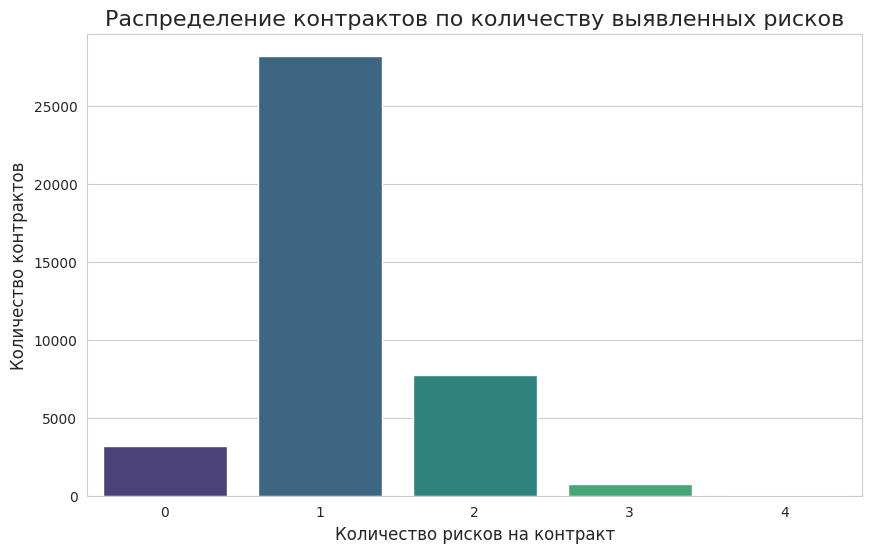


--- 2. Топ-10 Заказчиков по количеству рисковых контрактов ---
заказчик
РГП "Казаэронавигация"                                                                                                                                                                                                 148
ТОО "КАЖсервис"                                                                                                                                                                                                        133
РГП "Казгидромет"                                                                                                                                                                                                      117
Некоммерческое акционерное общество «Государственная корпорация «Правительство для граждан»                                                                                                                             85
Коммунальное государственное учреждение "Аппарат ак

,номер_договора,заказчик,поставщик,сумма,описание_закупки,способ_закупки,флаг_завышения_цены,флаг_частые_победы,флаг_дробление_закупок,флаг_низкая_конкуренция,количество_рисков
24647,180440012082/250174/00,"ТОО ""Транспортная компания города Усть-Каменог...","ООО "" ЧелябТрансСервис""",1535904.0,Неизвестно,Из одного источника по несостоявшимся закупкам,True,True,True,True,4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля для графиков
sns.set_style("whitegrid")

# --- 1. Распределение количества рисков ---
plt.figure(figsize=(10, 6))
sns.countplot(x='количество_рисков', data=df, palette='viridis')
plt.title('Распределение контрактов по количеству выявленных рисков', fontsize=16)
plt.xlabel('Количество рисков на контракт', fontsize=12)
plt.ylabel('Количество контрактов', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print("\n--- 2. Топ-10 Заказчиков по количеству рисковых контрактов ---")
top_risky_customers = df[df['есть_риски'] == True]['заказчик'].value_counts().head(10)
print(top_risky_customers)

print("\n--- 3. Топ-10 Поставщиков по количеству рисковых контрактов ---")
top_risky_suppliers = df[df['есть_риски'] == True]['поставщик'].value_counts().head(10)
print(top_risky_suppliers)

# Выведем подробнее один из контрактов с 4 рисками, если таковые есть
# Это будет отличным примером для демонстрации
print("\n--- 4. Детальный пример контракта с максимальным количеством рисков ---")
max_risk_contract = df[df['количество_рисков'] == df['количество_рисков'].max()].sample(1)
if not max_risk_contract.empty:
    display(max_risk_contract[['номер_договора', 'заказчик', 'поставщик', 'сумма',
                               'описание_закупки', 'способ_закупки',
                               'флаг_завышения_цены', 'флаг_частые_победы',
                               'флаг_дробление_закупок', 'флаг_низкая_конкуренция',
                               'количество_рисков']])
else:
    print("Не найдено контрактов с максимальным количеством рисков для демонстрации.")

In [ ]:
import pandas as pd
from google.colab import files

# скачал файлы из locals df
if 'df' in locals() and not df.empty:
    output_file_name = 'goszakup_contracts_FINAL_ANALYSIS.csv'
    df.to_csv(output_file_name, index=False, encoding='utf-8')
    print(f"DataFrame с финальными результатами анализа успешно сохранен как '{output_file_name}'.")

    files.download(output_file_name)
    print("Файл доступен для скачивания на ваш компьютер.")
else:
    print("Ошибка: DataFrame 'df' не найден")

DataFrame с финальными результатами анализа успешно сохранен как 'goszakup_contracts_FINAL_ANALYSIS.csv'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл доступен для скачивания на ваш компьютер.


**создание ui с помощью ngrok,streamlit**

---


In [ ]:
from pyngrok import ngrok
import os
from google.colab import userdata
import subprocess
import time
import sys

e = None

# Получаем токен ngrok из Colab secrets
NGROK_AUTH_TOKEN = None
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        print("Ngrok Authtoken успешно получен из Colab secrets.")
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    else:
        print("Ошибка: NGROK_AUTH_TOKEN не найден в Colab secrets.")
        print("Пожалуйста, добавьте ваш ngrok authtoken в Colab Secrets (иконка ключа слева) с именем NGROK_AUTH_TOKEN.")
except Exception as exc: # интересный факт если это переименовать то выйдет неизвестная ошибка!
    print(f"Ошибка при получении NGROK_AUTH_TOKEN из userdata: {exc}")
    print("Убедитесь, что вы правильно добавили токен в Colab secrets.")
    e = str(exc) # на всякий случай


# Чекаем токен
if NGROK_AUTH_TOKEN:
    try:
        print("Запуск Streamlit в фоновом режиме...")
        process = subprocess.Popen(['streamlit', 'run', 'app.py'],
                                   stdout=subprocess.PIPE,
                                   stderr=subprocess.PIPE,
                                   bufsize=1,
                                   universal_newlines=True
                                  )

        # Даем Streamlit немного времени на запуск (можно увеличить, если приложение большое)
        print("Ожидание запуска Streamlit (5 секунд)...")
        time.sleep(5)

        public_url = None
        for _ in range(5):
            try:
                ngrok.kill()
                public_url = ngrok.connect(8501)
                break # Если успешно подключились, выходим из цикла
            except Exception as ngrok_connect_e:
                print(f"Попытка подключения ngrok не удалась: {ngrok_connect_e}. Повторная попытка через 2 секунды...")
                time.sleep(2)

        if public_url:
            print(f"Ваше Streamlit-приложение доступно по адресу: {public_url}")
            print("Убедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.")
        else:
            print("Не удалось получить публичный URL ngrok после нескольких попыток.")
            print("Проверьте логи Streamlit и ngrok для получения дополнительной информации:")
            stdout, stderr = process.communicate(timeout=10)
            if stdout:
                print("\n--- Streamlit stdout ---")
                print(stdout)
            if stderr:
                print("\n--- Streamlit stderr ---")
                print(stderr)
            print("Возможно, Streamlit не запустился или файл данных отсутствует.")

    except FileNotFoundError:
        print("Ошибка: Команда 'streamlit' не найдена. Убедитесь, что streamlit установлен.")
    except Exception as e:
        print(f"Произошла непредвиденная ошибка при запуске Streamlit: {e}")
else:
    print("Не удалось запустить Streamlit, так как токен ngrok не был успешно получен. Пожалуйста, проверьте ваш NGROK_AUTH_TOKEN в Colab Secrets.")

ModuleNotFoundError: No module named 'pyngrok'

*кастомные эксперименты -можно не читать-*

**проверка завышенных цен к примеру на бензин::**

In [ ]:
if 'описание_закупки' in suspicious_prices_df.columns:
    benzine_cases = suspicious_prices_df[suspicious_prices_df['описание_закупки'].str.contains('бензин|топлив|гсм', na=False, case=False)]
    if not benzine_cases.empty:
        print("\n--- Потенциально завышенные цены на бензин/топливо ---")
        print(benzine_cases[['описание_закупки', 'сумма', 'количество', 'единица_измерения', 'цена_за_единицу', 'кластер_товара', 'заказчик', 'поставщик', 'способ_закупки']].to_string())
    else:
        print("\nЗакупок бензина/топлива с завышенными ценами не найдено.")


--- Потенциально завышенные цены на бензин/топливо ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        описание_закупки        сумма количество единица_измерения  цена_за_единицу кластер_товара                                                                                                                                                              

2025-06-22 12:14:58.676 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-06-22 12:14:58.683 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-06-22 12:14:58.684 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-22 12:14:58.789 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-06-22 12:14:58.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-22 12:14:58.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-22 12:14:58.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-22 12:14:59.294 Thread 'Thread-10': missing

DeltaGenerator()

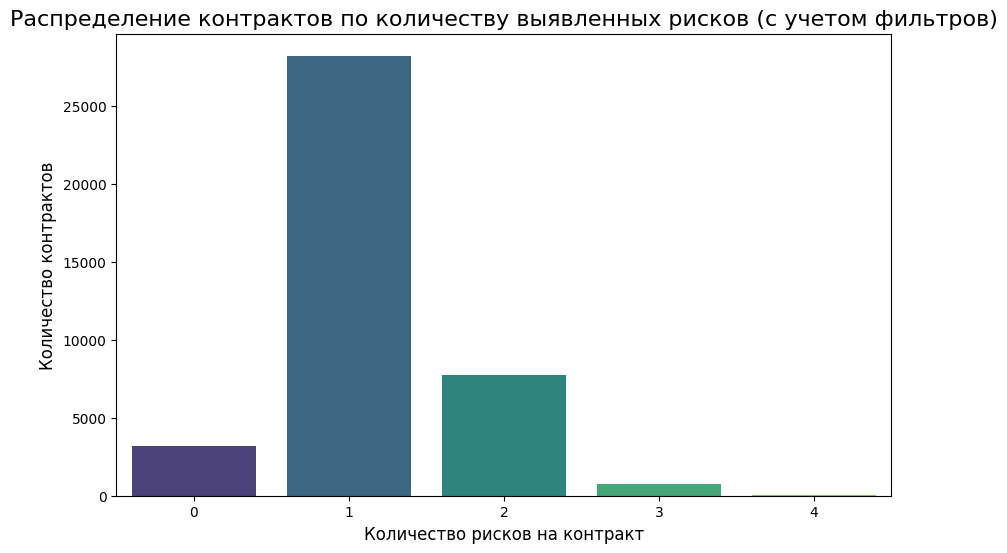

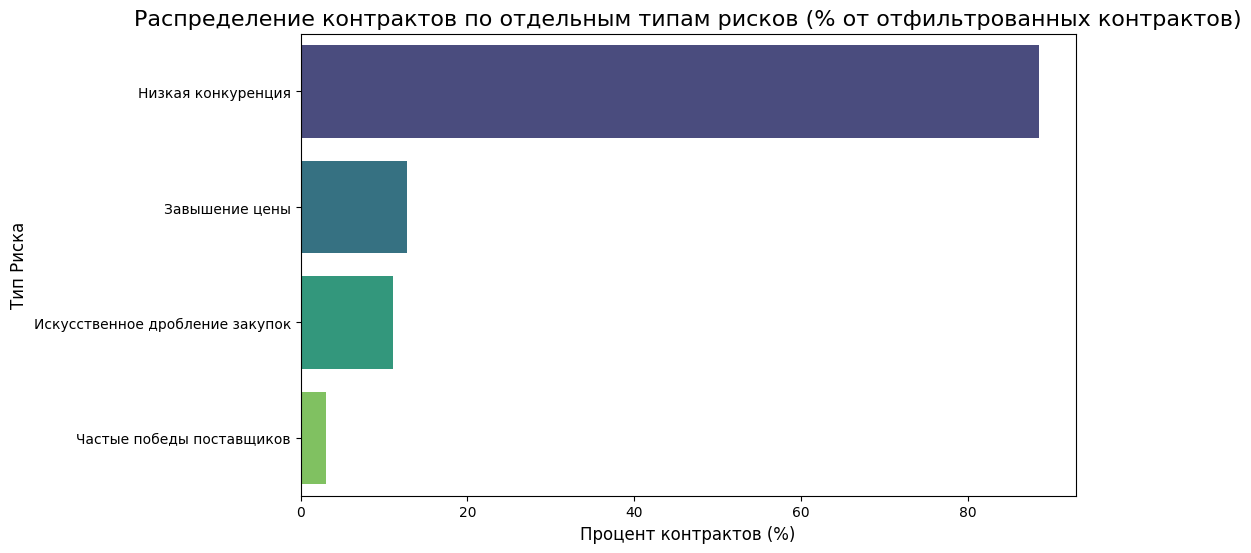

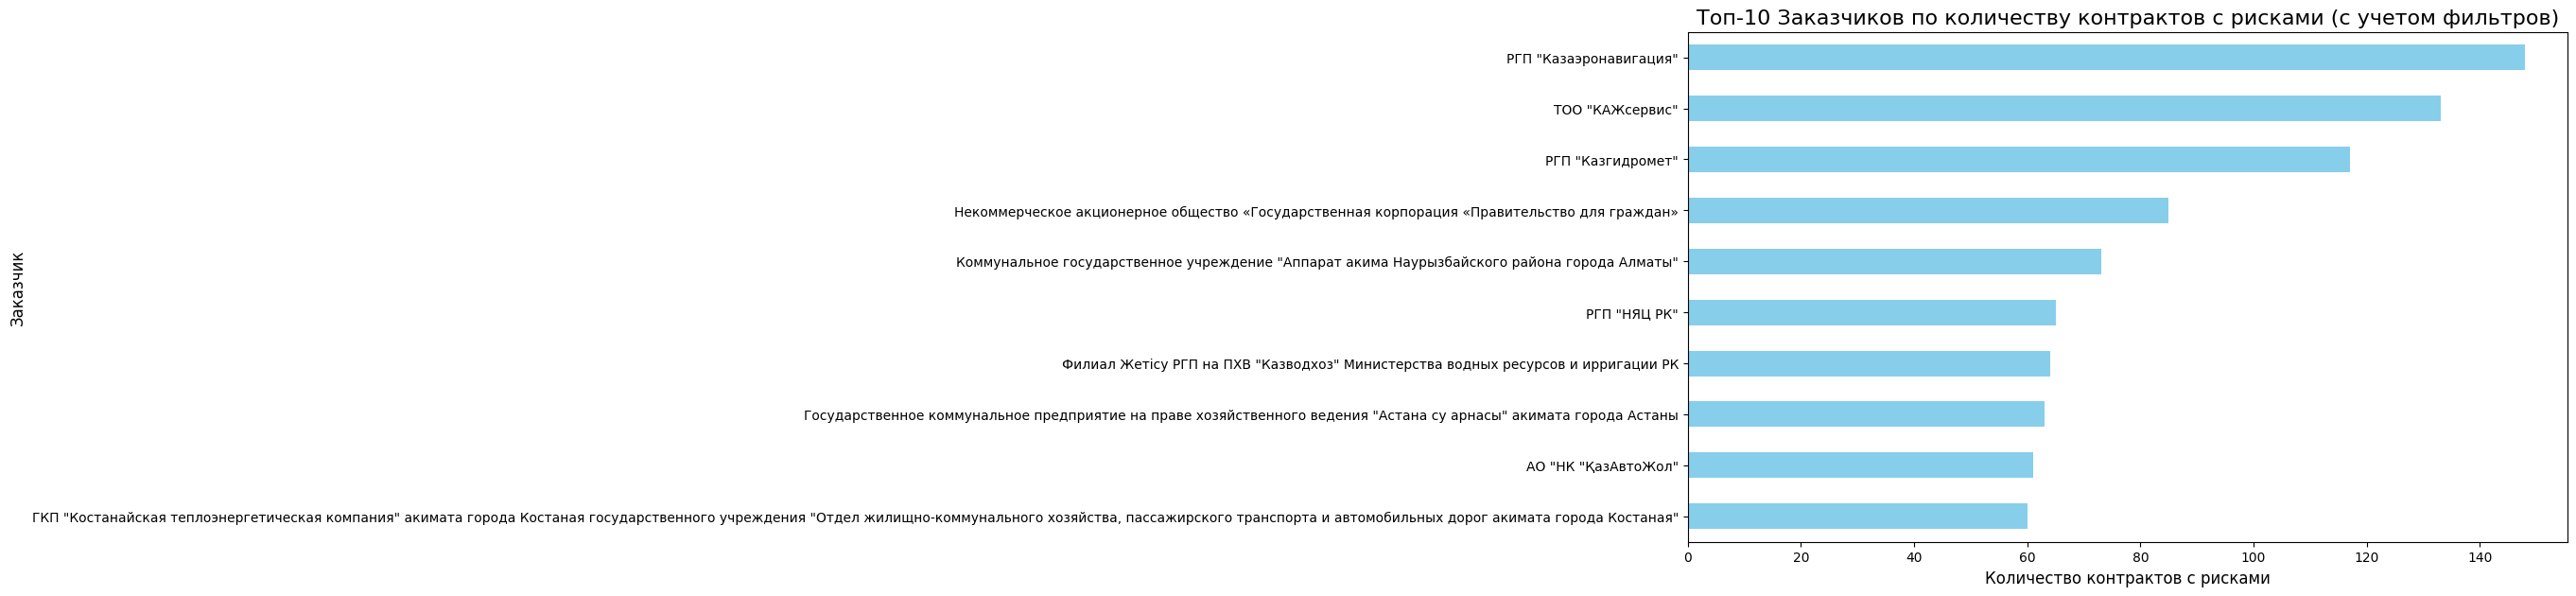

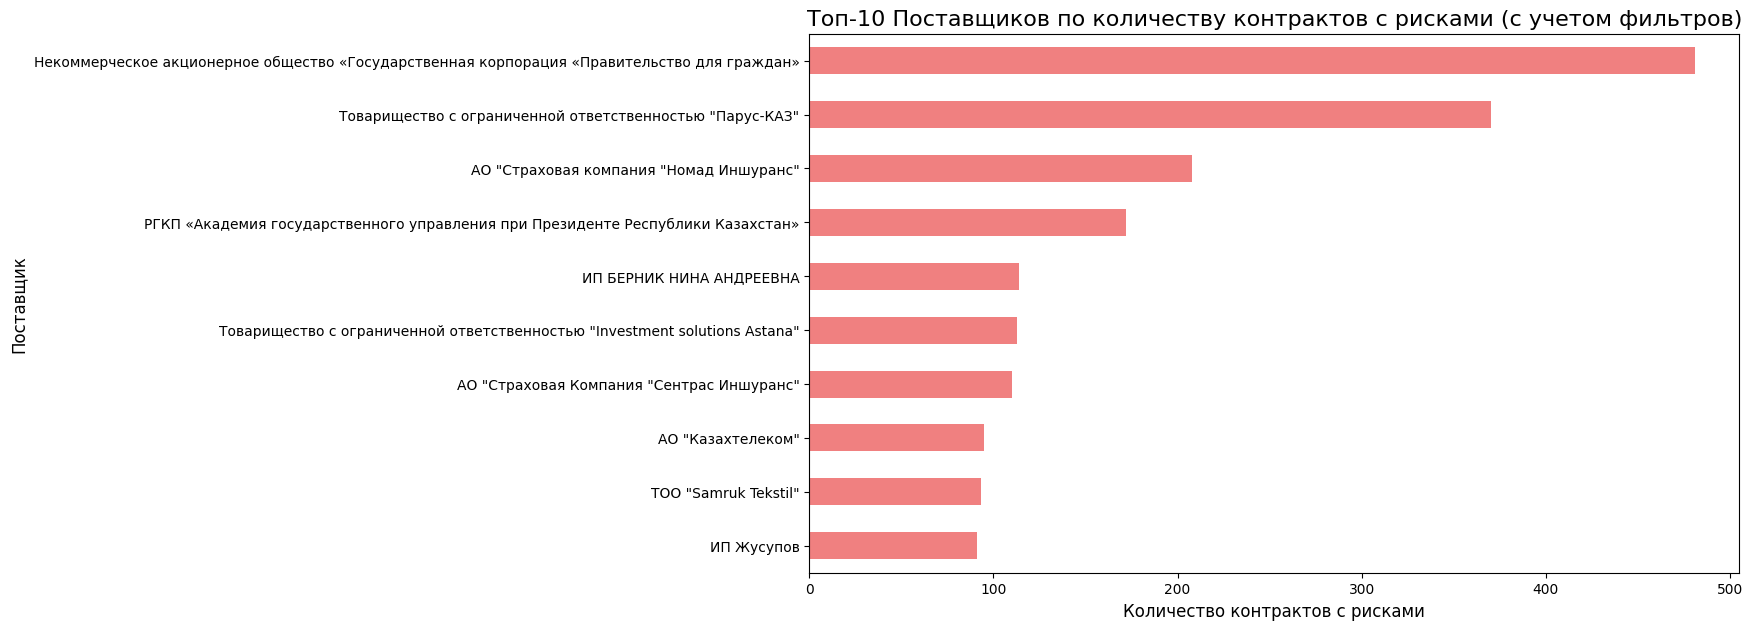

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем ваш обработанный DataFrame
@st.cache_data # Кэшируем данные, чтобы не перезагружать их при каждом изменении UI
def load_data():
    try:
        # Убедитесь, что имя файла совпадает с тем, что вы сохранили
        df = pd.read_csv('goszakup_contracts_FINAL_ANALYSIS.csv')
        df['дата_создания'] = pd.to_datetime(df['дата_создания'])
        # Убедитесь, что все флаги имеют правильный тип для суммирования
        for flag_col in ['флаг_завышения_цены', 'флаг_частые_победы', 'флаг_дробление_закупок', 'флаг_низкая_конкуренция']:
             if flag_col in df.columns:
                 df[flag_col] = df[flag_col].fillna(False).astype(bool)
             else:
                 st.warning(f"Предупреждение: Столбец '{flag_col}' не найден в загруженном DataFrame.")
                 df[flag_col] = False # Добавим столбец с False, если он отсутствует

        df['количество_рисков'] = (
            df['флаг_завышения_цены'].astype(int) +
            df['флаг_частые_победы'].astype(int) +
            df['флаг_дробление_закупок'].astype(int) +
            df['флаг_низкая_конкуренция'].astype(int)
        )
        df['есть_риски'] = df['количество_рисков'] > 0
        return df
    except FileNotFoundError:
        st.error("Файл 'goszakup_contracts_FINAL_ANALYSIS.csv' не найден. Убедитесь, что он загружен в среду Colab или правильно назван.")
        st.stop()
    except Exception as e:
        # ИСПРАВЛЕНИЕ: Экранируем фигурные скобки вокруг None
        # FIX: Escape curly braces inside the f-string
        st.error(f"Ошибка при загрузке или обработке данных: {e}")
        st.stop()

df = load_data()

# --- Streamlit UI ---
st.set_page_config(layout="wide")
st.title("Анализ рисков в государственных закупках Казахстана 🇰🇿")
st.markdown("### Инструмент для выявления потенциальных коррупционных схем и неэффективных закупок")

# Добавляем пояснение к шкале рисков
st.markdown(r"""
**Шкала оценки рисков:** Каждый контракт оценивается по количеству выявленных потенциальных аномалий, от 0 до 4:
- **0 рисков:** Контракт не соответствует ни одному из выявленных индикаторов риска.
- **1 риск:** Контракт соответствует одному индикатору риска (например, только потенциально завышенная цена).
- **2 риска:** Контракт соответствует двум индикаторам риска (например, завышенная цена + низкая конкуренция).
- **3 риска:** Контракт соответствует трем индикаторам риска.
- **4 риска:** Контракт соответствует всем четырем индикаторам риска (наиболее подозрительные).

Эта числовая шкала (от 0 до 4) предоставляет более гранулированную оценку по сравнению с простой "светофорной" системой (низкий/средний/высокий). Она позволяет точнее приоритизировать контракты для дальнейшего изучения и видеть, какие именно комбинации рисков встречаются чаще. Чем выше балл, тем больше оснований для более тщательной проверки.
""")

st.sidebar.header("Настройки и фильтры")
min_risks = st.sidebar.slider("Минимальное количество рисков", 0, 4, 0)
filtered_df = df[df['количество_рисков'] >= min_risks]

st.header("Общая статистика рисков")
col1, col2 = st.columns(2)
with col1:
    # ИСПРАВЛЕНИЕ: Экранируем фигурные скобки внутри f-строки
    # FIX: Escape curly braces inside the f-string
    st.metric(label="Всего контрактов", value=f"{len(df):,}".replace(",", " "))
with col2:
    # Use filtered_df for metrics based on filters
    risky_contracts_count = filtered_df['есть_риски'].sum()
    # Percentage of total contracts
    risky_contracts_percent = (risky_contracts_count / len(df)) * 100
    # ИСПРАВЛЕНИЕ: Экранируем фигурные скобки внутри f-строки
    # FIX: Escape curly braces inside the f-string
    st.metric(label="Контрактов с хотя бы 1 риском (с учетом фильтров)", value=f"{risky_contracts_count:,} ({risky_contracts_percent:.1f}%)".replace(",", " ")) # Adjusted label

st.markdown("---")

# 1.Распределение количества рисков
st.header("Распределение контрактов по количеству выявленных рисков")
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.countplot(x='количество_рисков', data=filtered_df, palette='viridis', ax=ax1)
ax1.set_title('Распределение контрактов по количеству выявленных рисков (с учетом фильтров)', fontsize=16) # Adjusted title
ax1.set_xlabel('Количество рисков на контракт', fontsize=12)
ax1.set_ylabel('Количество контрактов', fontsize=12)
st.pyplot(fig1)

st.markdown("---")

# --- Новый раздел: Анализ по типам рисков ---
st.header("Анализ по отдельным типам рисков")

# Создаем DataFrame для хранения результатов по типам рисков из filtered_df
risk_type_counts_filtered = pd.DataFrame({
    'Тип Риска': [
        'Завышение цены',
        'Частые победы поставщиков',
        'Искусственное дробление закупок',
        'Низкая конкуренция'
    ],
    'Количество Контрактов': [
        filtered_df['флаг_завышения_цены'].sum(),
        filtered_df['флаг_частые_победы'].sum(),
        filtered_df['флаг_дробление_закупок'].sum(),
        filtered_df['флаг_низкая_конкуренция'].sum()
    ]
})

# Рассчитываем процент от общего числа контрактов в ОТФИЛЬТРОВАННОМ DataFrame
total_filtered_contracts = len(filtered_df)
if total_filtered_contracts > 0:
    risk_type_counts_filtered['Процент (%)'] = (risk_type_counts_filtered['Количество Контрактов'] / total_filtered_contracts) * 100
else:
     risk_type_counts_filtered['Процент (%)'] = 0 # Avoid division by zero

# Сортируем по количеству для удобства просмотра
risk_type_counts_filtered = risk_type_counts_filtered.sort_values(by='Количество Контрактов', ascending=False)

st.dataframe(risk_type_counts_filtered)

# Визуализация распределения по типам рисков
if total_filtered_contracts > 0 and risk_type_counts_filtered['Количество Контрактов'].sum() > 0:
    fig_risk_types, ax_risk_types = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Процент (%)', y='Тип Риска', data=risk_type_counts_filtered, palette='viridis', ax=ax_risk_types)
    ax_risk_types.set_title('Распределение контрактов по отдельным типам рисков (% от отфильтрованных контрактов)', fontsize=16)
    ax_risk_types.set_xlabel('Процент контрактов (%)', fontsize=12)
    ax_risk_types.set_ylabel('Тип Риска', fontsize=12)
    st.pyplot(fig_risk_types)
else:
    st.info("Нет данных для отображения распределения по типам рисков в текущих фильтрах.")


st.markdown("---")

# 2. Топ Заказчиков
st.header("Ключевые игроки с высоким риском")

# Топ-10 Заказчиков
st.subheader("Топ-10 Заказчиков по количеству рисковых контрактов")
top_risky_customers = filtered_df[filtered_df['есть_риски'] == True]['заказчик'].value_counts().head(10)
if not top_risky_customers.empty:
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    top_risky_customers.plot(kind='barh', color='skyblue', ax=ax2)
    ax2.set_title('Топ-10 Заказчиков по количеству контрактов с рисками (с учетом фильтров)', fontsize=16) # Adjusted title
    ax2.set_xlabel('Количество контрактов с рисками', fontsize=12)
    ax2.set_ylabel('Заказчик', fontsize=12)
    ax2.invert_yaxis()
    st.pyplot(fig2)
else:
    st.info("Нет заказчиков с рисками, соответствующими текущим фильтрам.")

# Топ-10 Поставщиков
st.subheader("Топ-10 Поставщиков по количеству рисковых контрактов")
top_risky_suppliers = filtered_df[filtered_df['есть_риски'] == True]['поставщик'].value_counts().head(10)
if not top_risky_suppliers.empty:
    fig3, ax3 = plt.subplots(figsize=(12, 7))
    top_risky_suppliers.plot(kind='barh', color='lightcoral', ax=ax3)
    ax3.set_title('Топ-10 Поставщиков по количеству контрактов с рисками (с учетом фильтров)', fontsize=16) # Adjusted title
    ax3.set_xlabel('Количество контрактов с рисками', fontsize=12)
    ax3.set_ylabel('Поставщик', fontsize=12)
    ax3.invert_yaxis()
    st.pyplot(fig3)
else:
    st.info("Нет поставщиков с рисками, соответствующими текущим фильтрам.")


st.markdown("---")

# 3.Примеры с высоким риском
st.header("Примеры контрактов с высоким риском")
st.write("Ниже представлены контракты, которые имеют максимальное количество выявленных рисков. Это позволяет наглядно увидеть сработавшие индикаторы.")

max_risk_level = filtered_df['количество_рисков'].max()
if max_risk_level > 0:
    high_risk_contracts = filtered_df[filtered_df['количество_рисков'] == max_risk_level]
    if not high_risk_contracts.empty:
        display_contracts = high_risk_contracts.sample(min(5, len(high_risk_contracts)))
        st.dataframe(display_contracts[['номер_договора', 'заказчик', 'поставщик', 'сумма',
                                         'описание_закупки', 'способ_закупки',
                                         'флаг_завышения_цены', 'флаг_частые_победы',
                                         'флаг_дробление_закупок', 'флаг_низкая_конкуренция',
                                         'количество_рисков']])
    else:
        st.info("Не найдено контрактов с максимальным количеством рисков для демонстрации в текущих фильтрах.")
else:
    st.info("В текущих фильтрах нет контрактов с выявленными рисками.")

st.markdown("---")
st.info("Ваша модель успешно выявила потенциальные аномалии в госзакупках. Эти данные могут служить основой для дальнейшего расследования и повышения прозрачности.")

Maded by ml engineer [github](https://github.com/dxrkravehub)
---



In [ ]:
import pandas as pd

print("\n--- Анализ по типам рисков ---")

# Создаем DataFrame для хранения результатов
risk_type_counts = pd.DataFrame({
    'Тип Риска': [
        'Завышение цены',
        'Частые победы поставщиков',
        'Искусственное дробление закупок',
        'Низкая конкуренция'
    ],
    'Количество Контрактов': [
        df['флаг_завышения_цены'].sum(),
        df['флаг_частые_победы'].sum(),
        df['флаг_дробление_закупок'].sum(),
        df['флаг_низкая_конкуренция'].sum()
    ]
})

# Рассчитываем процент от общего числа контрактов
total_contracts = len(df)
risk_type_counts['Процент (%)'] = (risk_type_counts['Количество Контрактов'] / total_contracts) * 100

# Сортируем по количеству для удобства просмотра
risk_type_counts = risk_type_counts.sort_values(by='Количество Контрактов', ascending=False)

print("Распределение контрактов по отдельным типам рисков:")
display(risk_type_counts)

# Также можно показать общее количество контрактов с хотя бы одним риском (повторно, для полноты)
print(f"\nВсего контрактов: {total_contracts}")
print(f"Контрактов с хотя бы одним риском: {df['есть_риски'].sum()}")
print(f"Процент контрактов с хотя бы одним риском: {(df['есть_risks'].sum() / total_contracts) * 100:.2f}%")


--- Анализ по типам рисков ---


NameError: name 'df' is not defined

In [ ]:
import pandas as pd

# Загружаем DataFrame из файла
file_path = 'goszakup_contracts_FINAL_ANALYSIS.csv'

try:
    df = pd.read_csv(file_path)
    print(f"DataFrame успешно загружен из '{file_path}'.")

    # Убедимся, что флаги имеют правильный тип данных (bool) для суммирования
    # и что количество_рисков и есть_риски пересчитаны на случай, если они были потеряны при сохранении/загрузке
    for flag_col in ['флаг_завышения_цены', 'флаг_частые_победы', 'флаг_дробление_закупок', 'флаг_низкая_конкуренция']:
         if flag_col in df.columns:
             df[flag_col] = df[flag_col].fillna(False).astype(bool)
         else:
             print(f"Предупреждение: Столбец '{flag_col}' не найден в загруженном DataFrame.")
             df[flag_col] = False # Добавим столбец с False, если он отсутствует


    df['количество_рисков'] = (
        df['флаг_завышения_цены'].astype(int) +
        df['флаг_частые_победы'].astype(int) +
        df['флаг_дробление_закупок'].astype(int) +
        df['флаг_низкая_конкуренция'].astype(int)
    )
    df['есть_риски'] = df['количество_рисков'] > 0


    # Теперь выполним анализ по типам рисков
    print("\n--- Анализ по типам рисков ---")

    risk_type_counts = pd.DataFrame({
        'Тип Риска': [
            'Завышение цены',
            'Частые победы поставщиков',
            'Искусственное дробление закупок',
            'Низкая конкуренция'
        ],
        'Количество Контрактов': [
            df['флаг_завышения_цены'].sum(),
            df['флаг_частые_победы'].sum(),
            df['флаг_дробление_закупок'].sum(),
            df['флаг_низкая_конкуренция'].sum()
        ]
    })

    total_contracts = len(df)
    risk_type_counts['Процент (%)'] = (risk_type_counts['Количество Контрактов'] / total_contracts) * 100

    risk_type_counts = risk_type_counts.sort_values(by='Количество Контрактов', ascending=False)

    print("Распределение контрактов по отдельным типам рисков:")
    display(risk_type_counts)

    print(f"\nВсего контрактов: {total_contracts}")
    print(f"Контрактов с хотя бы одним риском: {df['есть_риски'].sum()}")
    print(f"Процент контрактов с хотя бы одним риском: {(df['есть_риски'].sum() / total_contracts) * 100:.2f}%")


except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден. Убедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' существует в текущей директории Colab.")
except Exception as e:
    print(f"Произошла ошибка при загрузке или обработке данных: {e}")

DataFrame успешно загружен из 'goszakup_contracts_FINAL_ANALYSIS.csv'.

--- Анализ по типам рисков ---
Распределение контрактов по отдельным типам рисков:


/tmp/ipython-input-7-791229603.py:7: DtypeWarning: Columns (19,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipython-input-7-791229603.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[flag_col] = df[flag_col].fillna(False).astype(bool)


,Тип Риска,Количество Контрактов,Процент (%)
3,Низкая конкуренция,35383,88.488471
0,Завышение цены,5119,12.801981
2,Искусственное дробление закупок,4407,11.021357
1,Частые победы поставщиков,1216,3.041064



Всего контрактов: 39986
Контрактов с хотя бы одним риском: 36771
Процент контрактов с хотя бы одним риском: 91.96%


In [ ]:
# Убедимся, что pyngrok и streamlit установлены
!pip install -q pyngrok streamlit

print("Необходимые библиотеки проверены/установлены.")

Необходимые библиотеки проверены/установлены.


In [ ]:
from pyngrok import ngrok
import os
from google.colab import userdata
import subprocess
import time
import sys

e = None

# Получаем токен ngrok из Colab secrets
NGROK_AUTH_TOKEN = None
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        print("Ngrok Authtoken успешно получен из Colab secrets.")
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    else:
        print("Ошибка: NGROK_AUTH_TOKEN не найден в Colab secrets.")
        print("Пожалуйста, добавьте ваш ngrok authtoken в Colab Secrets (иконка ключа слева) с именем NGROK_AUTH_TOKEN.")
except Exception as exc: # интересный факт если это переименовать то выйдет неизвестная ошибка!
    print(f"Ошибка при получении NGROK_AUTH_TOKEN из userdata: {exc}")
    print("Убедитесь, что вы правильно добавили токен в Colab secrets.")
    e = str(exc) # на всякий случай


# Чекаем токен
if NGROK_AUTH_TOKEN:
    # Проверяем существование файла app.py
    if not os.path.exists('app.py'):
        print("Ошибка: Файл 'app.py' не найден. Убедитесь, что вы создали файл с кодом Streamlit.")
    else:
        try:
            print("Запуск Streamlit в фоновом режиме...")
            # Используем sys.executable для запуска Streamlit с тем же Python, что и Colab
            process = subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'],
                                       stdout=subprocess.PIPE,
                                       stderr=subprocess.PIPE,
                                       bufsize=1,
                                       universal_newlines=True
                                      )

            # Даем Streamlit немного времени на запуск (можно увеличить, если приложение большое)
            print("Ожидание запуска Streamlit (10 секунд)...") # Увеличил время ожидания
            time.sleep(10)

            public_url = None
            # Увеличил количество попыток подключения ngrok
            for attempt in range(10):
                try:
                    ngrok.kill() # Убиваем предыдущие туннели ngrok
                    # Подключаемся к порту, на котором Streamlit обычно работает (8501)
                    public_url = ngrok.connect(8501)
                    print(f"DEBUG: ngrok connect attempt {attempt+1} successful.")
                    break # Если успешно подключились, выходим из цикла
                except Exception as ngrok_connect_e:
                    print(f"Попытка подключения ngrok не удалась (Попытка {attempt+1}): {ngrok_connect_e}. Повторная попытка через 5 секунд...") # Увеличил время паузы
                    time.sleep(5)

            if public_url:
                print(f"\nВаше Streamlit-приложение доступно по адресу: {public_url}")
                print("\nПожалуйста, откройте эту ссылку в вашем браузере.")
                print("\nУбедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.")
            else:
                print("\nНе удалось получить публичный URL ngrok после нескольких попыток.")
                print("Проверьте логи Streamlit и ngrok для получения дополнительной информации:")
                # Пытаемся прочитать вывод процесса, если он завершился
                try:
                    stdout, stderr = process.communicate(timeout=5) # Уменьшил таймаут для communicate
                    if stdout:
                        print("\n--- Streamlit stdout ---")
                        print(stdout)
                    if stderr:
                        print("\n--- Streamlit stderr ---")
                        print(stderr)
                except subprocess.TimeoutExpired:
                    print("Streamlit процесс все еще работает. Не удалось получить stdout/stderr сразу.")
                    print("Возможно, Streamlit запустился, но ngrok не смог к нему подключиться.")
                print("\nВозможно, Streamlit не запустился корректно, или есть проблемы с токеном ngrok, или файл данных отсутствует.")

        except FileNotFoundError:
            print("\nОшибка: Команда 'streamlit' не найдена. Убедитесь, что streamlit установлен.")
        except Exception as e:
            print(f"\nПроизошла непредвиденная ошибка при запуске Streamlit: {e}")
else:
    print("\nНе удалось запустить Streamlit, так как токен ngrok не был успешно получен. Пожалуйста, проверьте ваш NGROK_AUTH_TOKEN в Colab Secrets.")

Ngrok Authtoken успешно получен из Colab secrets.
Запуск Streamlit в фоновом режиме...
Ожидание запуска Streamlit (10 секунд)...


ERROR:pyngrok.process.ngrok:t=2025-06-22T12:32:28+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2025-06-22T12:32:28+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok st

Попытка подключения ngrok не удалась (Попытка 1): The ngrok process errored on start: authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n.. Повторная попытка через 5 секунд...
DEBUG: ngrok connect attempt 2 successful.

Ваше Streamlit-приложение доступно по адресу: NgrokTunnel: "https://29e9-34-86-198-74.ngrok-free.app" -> "http://localhost:8501"

Пожалуйста, откройте эту ссылку в вашем браузере.

Убедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.


In [ ]:
# Остановим текущий процесс Streamlit, если он запущен
if 'process' in locals() and process.poll() is None:
    print("Останавливаем текущий процесс Streamlit...")
    process.terminate()
    try:
        process.wait(timeout=5)
        print("Процесс Streamlit остановлен.")
    except subprocess.TimeoutExpired:
        print("Не удалось остановить процесс Streamlit, возможно, потребуется ручная остановка.")

# Остановим все текущие туннели ngrok
try:
    print("Останавливаем текущие туннели ngrok...")
    ngrok.kill()
    print("Туннели ngrok остановлены.")
except Exception as e:
    print(f"Ошибка при остановке туннелей ngrok (возможно, их не было): {e}")

# Теперь запустим Streamlit и ngrok заново
from pyngrok import ngrok
import os
from google.colab import userdata
import subprocess
import time
import sys

e = None

# Получаем токен ngrok из Colab secrets
NGROK_AUTH_TOKEN = None
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        print("Ngrok Authtoken успешно получен из Colab secrets.")
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    else:
        print("Ошибка: NGROK_AUTH_TOKEN не найден в Colab secrets.")
        print("Пожалуйста, добавьте ваш ngrok authtoken в Colab Secrets (иконка ключа слева) с именем NGROK_AUTH_TOKEN.")
except Exception as exc:
    print(f"Ошибка при получении NGROK_AUTH_TOKEN из userdata: {exc}")
    print("Убедитесь, что вы правильно добавили токен в Colab secrets.")
    e = str(exc)

# Чекаем токен
if NGROK_AUTH_TOKEN:
    # Проверяем существование файла app.py
    if not os.path.exists('app.py'):
        print("Ошибка: Файл 'app.py' не найден. Убедитесь, что вы создали файл с кодом Streamlit.")
    else:
        try:
            print("Запуск Streamlit в фоновом режиме...")
            # Используем sys.executable для запуска Streamlit с тем же Python, что и Colab
            process = subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'],
                                       stdout=subprocess.PIPE,
                                       stderr=subprocess.PIPE,
                                       bufsize=1,
                                       universal_newlines=True
                                      )

            print("Ожидание запуска Streamlit (10 секунд)...")
            time.sleep(10)

            public_url = None
            for attempt in range(10):
                try:
                    # ngrok.kill() # Уже убили выше
                    public_url = ngrok.connect(8501)
                    print(f"DEBUG: ngrok connect attempt {attempt+1} successful.")
                    break
                except Exception as ngrok_connect_e:
                    print(f"Попытка подключения ngrok не удалась (Попытка {attempt+1}): {ngrok_connect_e}. Повторная попытка через 5 секунд...")
                    time.sleep(5)

            if public_url:
                print(f"\nВаше Streamlit-приложение доступно по адресу: {public_url}")
                print("\nПожалуйста, откройте эту ссылку в вашем браузере и обновите страницу.")
                print("\nУбедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.")
            else:
                print("\nНе удалось получить публичный URL ngrok после нескольких попыток.")
                print("Проверьте логи Streamlit и ngrok для получения дополнительной информации:")
                try:
                    stdout, stderr = process.communicate(timeout=5)
                    if stdout:
                        print("\n--- Streamlit stdout ---")
                        print(stdout)
                    if stderr:
                        print("\n--- Streamlit stderr ---")
                        print(stderr)
                except subprocess.TimeoutExpired:
                    print("Streamlit процесс все еще работает. Не удалось получить stdout/stderr сразу.")
                    print("Возможно, Streamlit запустился, но ngrok не смог к нему подключиться.")
                print("\nВозможно, Streamlit не запустился корректно, или есть проблемы с токеном ngrok, или файл данных отсутствует.")

        except FileNotFoundError:
            print("\nОшибка: Команда 'streamlit' не найдена. Убедитесь, что streamlit установлен.")
        except Exception as e:
            print(f"\nПроизошла непредвиденная ошибка при запуске Streamlit: {e}")
else:
    print("\nНе удалось запустить Streamlit, так как токен ngrok не был успешно получен. Пожалуйста, проверьте ваш NGROK_AUTH_TOKEN в Colab Secrets.")

Останавливаем текущий процесс Streamlit...
Процесс Streamlit остановлен.
Останавливаем текущие туннели ngrok...
Туннели ngrok остановлены.
Ngrok Authtoken успешно получен из Colab secrets.
Запуск Streamlit в фоновом режиме...
Ожидание запуска Streamlit (10 секунд)...
DEBUG: ngrok connect attempt 1 successful.

Ваше Streamlit-приложение доступно по адресу: NgrokTunnel: "https://389e-34-86-198-74.ngrok-free.app" -> "http://localhost:8501"

Пожалуйста, откройте эту ссылку в вашем браузере и обновите страницу.

Убедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.


In [ ]:
# Остановим текущий процесс Streamlit, если он запущен
if 'process' in locals() and process.poll() is None:
    print("Останавливаем текущий процесс Streamlit...")
    process.terminate()
    try:
        process.wait(timeout=5)
        print("Процесс Streamlit остановлен.")
    except subprocess.TimeoutExpired:
        print("Не удалось остановить процесс Streamlit, возможно, потребуется ручная остановка.")

# Остановим все текущие туннели ngrok
try:
    print("Останавливаем текущие туннели ngrok...")
    ngrok.kill()
    print("Туннели ngrok остановлены.")
except Exception as e:
    print(f"Ошибка при остановке туннелей ngrok (возможно, их не было): {e}")

# Теперь запустим Streamlit и ngrok заново
from pyngrok import ngrok
import os
from google.colab import userdata
import subprocess
import time
import sys

e = None

# Получаем токен ngrok из Colab secrets
NGROK_AUTH_TOKEN = None
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        print("Ngrok Authtoken успешно получен из Colab secrets.")
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    else:
        print("Ошибка: NGROK_AUTH_TOKEN не найден в Colab secrets.")
        print("Пожалуйста, добавьте ваш ngrok authtoken в Colab Secrets (иконка ключа слева) с именем NGROK_AUTH_TOKEN.")
except Exception as exc:
    print(f"Ошибка при получении NGROK_AUTH_TOKEN из userdata: {exc}")
    print("Убедитесь, что вы правильно добавили токен в Colab secrets.")
    e = str(exc)

# Чекаем токен
if NGROK_AUTH_TOKEN:
    # Проверяем существование файла app.py
    if not os.path.exists('app.py'):
        print("Ошибка: Файл 'app.py' не найден. Убедитесь, что вы создали файл с кодом Streamlit.")
    else:
        try:
            print("Запуск Streamlit в фоновом режиме...")
            # Используем sys.executable для запуска Streamlit с тем же Python, что и Colab
            process = subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'],
                                       stdout=subprocess.PIPE,
                                       stderr=subprocess.PIPE,
                                       bufsize=1,
                                       universal_newlines=True
                                      )

            print("Ожидание запуска Streamlit (10 секунд)...")
            time.sleep(10)

            public_url = None
            for attempt in range(10):
                try:
                    # ngrok.kill() # Уже убили выше
                    public_url = ngrok.connect(8501)
                    print(f"DEBUG: ngrok connect attempt {attempt+1} successful.")
                    break
                except Exception as ngrok_connect_e:
                    print(f"Попытка подключения ngrok не удалась (Попытка {attempt+1}): {ngrok_connect_e}. Повторная попытка через 5 секунд...")
                    time.sleep(5)

            if public_url:
                print(f"\nВаше Streamlit-приложение доступно по адресу: {public_url}")
                print("\nПожалуйста, откройте эту ссылку в вашем браузере и обновите страницу.")
                print("\nУбедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.")
            else:
                print("\nНе удалось получить публичный URL ngrok после нескольких попыток.")
                print("Проверьте логи Streamlit и ngrok для получения дополнительной информации:")
                try:
                    stdout, stderr = process.communicate(timeout=5)
                    if stdout:
                        print("\n--- Streamlit stdout ---")
                        print(stdout)
                    if stderr:
                        print("\n--- Streamlit stderr ---")
                        print(stderr)
                except subprocess.TimeoutExpired:
                    print("Streamlit процесс все еще работает. Не удалось получить stdout/stderr сразу.")
                    print("Возможно, Streamlit запустился, но ngrok не смог к нему подключиться.")
                print("\nВозможно, Streamlit не запустился корректно, или есть проблемы с токеном ngrok, или файл данных отсутствует.")

        except FileNotFoundError:
            print("\nОшибка: Команда 'streamlit' не найдена. Убедитесь, что streamlit установлен.")
        except Exception as e:
            print(f"\nПроизошла непредвиденная ошибка при запуске Streamlit: {e}")
else:
    print("\nНе удалось запустить Streamlit, так как токен ngrok не был успешно получен. Пожалуйста, проверьте ваш NGROK_AUTH_TOKEN в Colab Secrets.")

Останавливаем текущий процесс Streamlit...
Процесс Streamlit остановлен.
Останавливаем текущие туннели ngrok...
Туннели ngrok остановлены.
Ngrok Authtoken успешно получен из Colab secrets.
Запуск Streamlit в фоновом режиме...
Ожидание запуска Streamlit (10 секунд)...
DEBUG: ngrok connect attempt 1 successful.

Ваше Streamlit-приложение доступно по адресу: NgrokTunnel: "https://75d5-34-86-198-74.ngrok-free.app" -> "http://localhost:8501"

Пожалуйста, откройте эту ссылку в вашем браузере и обновите страницу.

Убедитесь, что файл 'goszakup_contracts_FINAL_ANALYSIS.csv' загружен в вашу среду Colab.
